Using Stanford dogs dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/DL-dataset/stanford-dogs-dataset.zip -d /content/drive/MyDrive/DL-dataset/

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_11687.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_117.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_11807.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_11875.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_122.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_12232.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_125.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_12738.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02108089-boxer/n02108089_12739.jpg  
  inflating: /content/drive/MyDrive/DL-dataset/images/Images/n02

In [ ]:
import os

base_path = "/content/drive/MyDrive/DL-dataset"
print(os.listdir(base_path))

['stanford-dogs-dataset.zip', 'annotations', 'images']


In [ ]:
data_path = "/content/drive/MyDrive/DL-dataset/train_fixed"

In [ ]:
import tensorflow as tf

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(64, 64),
    batch_size=32
)

Found 20580 files belonging to 120 classes.


Week - 1

In [ ]:
import tensorflow as tf

data_path = "/content/drive/MyDrive/DL-dataset/train_fixed"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(64, 64),
    batch_size=32
)

dataset = dataset.map(lambda x, y: (x / 255.0, y))

dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 20580 files belonging to 120 classes.


In [ ]:
train_size = int(0.8 * len(dataset))

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(120, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 151s 289ms/step - accuracy: 0.0117 - loss: 4.8054 - val_accuracy: 0.0127 - val_loss: 4.7707
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.0187 - loss: 4.7111 - val_accuracy: 0.0154 - val_loss: 4.6771
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.0220 - loss: 4.6119 - val_accuracy: 0.0176 - val_loss: 4.6199
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.0234 - loss: 4.5774 - val_accuracy: 0.0200 - val_loss: 4.6034
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.0279 - loss: 4.5284 - val_accuracy: 0.0244 - val_loss: 4.6046


here accuracy is very low bcz the model fails to capture spatial relationships in image data

loss decreases gradually, but validation loss fluctuates, indicating poor generalization

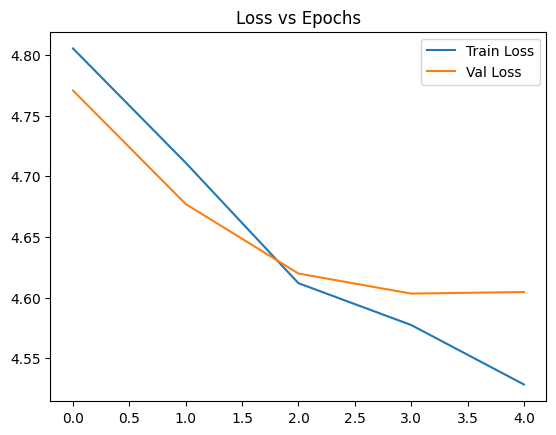

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

# Week 2 programs

Binary Classification on dog dataset

In [ ]:
import tensorflow as tf

data_path = "/content/drive/MyDrive/DL-dataset/train_fixed"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(64, 64),
    batch_size=32
)

class_names = dataset.class_names
print(class_names[0])  # target breed

Found 20580 files belonging to 120 classes.
n02085620-Chihuahua


In [ ]:
#convert to binary
def to_binary(x, y):
    return x, tf.cast(y == 0, tf.int32)  # class 0 vs rest

dataset = dataset.map(lambda x, y: (x / 255.0, y))
binary_ds = dataset.map(to_binary)

In [ ]:
#flatten input
binary_ds = binary_ds.map(lambda x, y: (tf.reshape(x, [tf.shape(x)[0], -1]), y))

I flattened the input images into 1D arrays to test simpler ML models, resulting in a shape of (6400, 12288)

In [ ]:
#converting to numpy
import numpy as np

X_list = []
y_list = []

for x, y in binary_ds.take(200):  # limit for speed
    X_list.append(x.numpy())
    y_list.append(y.numpy())

X = np.vstack(X_list)
y = np.hstack(y_list)

print(X.shape, y.shape)

(6400, 12288) (6400,)


In [ ]:
# MP Perceptron (No Weights/Bias Concept)
def mp_perceptron(x):
    return 1 if np.sum(x) > 500 else 0  # arbitrary threshold

preds = np.array([mp_perceptron(x) for x in X[:50]])

print(preds[:10])
print(y[:10])

[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]


I tried running a basic Perceptron (both with and without weights/bias), but the output arrays were literally just all zeros, It wasn't learning anything useful

In [ ]:
# Perceptron (WITH WEIGHTS)
from sklearn.linear_model import Perceptron

model = Perceptron(fit_intercept=False, max_iter=1000)
model.fit(X, y)

preds = model.predict(X[:50])
print(preds)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
model_bias = Perceptron(fit_intercept=True, max_iter=1000)
model_bias.fit(X, y)

preds_bias = model_bias.predict(X[:50])
print(preds_bias)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print("Number of 1s:", np.sum(y == 1))
print("Number of 0s:", np.sum(y == 0))

Number of 1s: 54
Number of 0s: 6346


In [ ]:
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

# Take equal samples
n = min(len(pos_idx), len(neg_idx), 200)

selected_idx = np.concatenate([
    pos_idx[:n],
    neg_idx[:n]
])

X_bal = X[selected_idx]
y_bal = y[selected_idx]

print(X_bal.shape, y_bal.shape)

(108, 12288) (108,)


In [ ]:
model = Perceptron(fit_intercept=True, max_iter=1000)
model.fit(X_bal, y_bal)

preds = model.predict(X_bal[:20])
print(preds)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# The perceptron predicted all zeros due to lack of
# linear separability and inability to handle complex image data, even after balancing

In [ ]:
sample = X[0].reshape(1, -1)

print("Prediction:", model_bias.predict(sample))
print("Actual:", y[0])

Prediction: [0]
Actual: 0


# Week 3 MLP + LR + Convergence

In [ ]:
#load ds
import tensorflow as tf

data_path = "/content/drive/MyDrive/DL-dataset/train_fixed"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(64, 64),
    batch_size=32
)

dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Split
train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

Found 20580 files belonging to 120 classes.


In [ ]:
def train_model(lr):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(120, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5, #training on 5 epochs only
        verbose=0
    )

    return history

In [ ]:
lrs = [0.0001, 0.001, 0.01] #i am using different learning rates to observe the difference
histories = {}

for lr in lrs:
    print(f"Training with LR = {lr}")
    histories[lr] = train_model(lr)

Training with LR = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with LR = 0.001
Training with LR = 0.01


In [ ]:
# Observation
#learning rate = 0.0001 Training is very slow and loss decreases gradually, convergence is stable but takes longer time.
#learning rate = 0.001 Model converges efficiently with steady decrease in loss, provides a balance between speed and stability
#learning rate = 0.01 loss fluctuates, it is not converging properly due to large updates, it is unstable

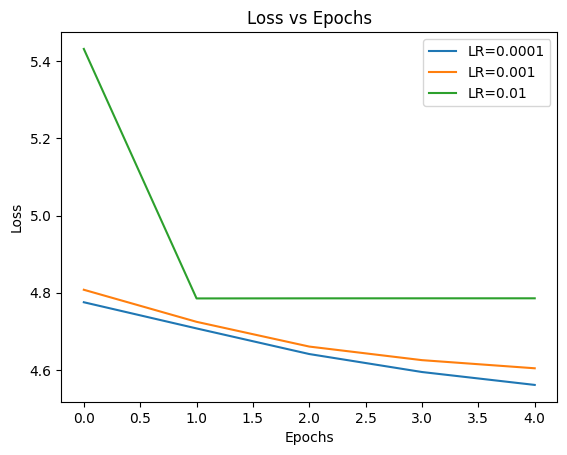

In [ ]:
#plot graph
import matplotlib.pyplot as plt

for lr in lrs:
    plt.plot(histories[lr].history['loss'], label=f"LR={lr}")

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

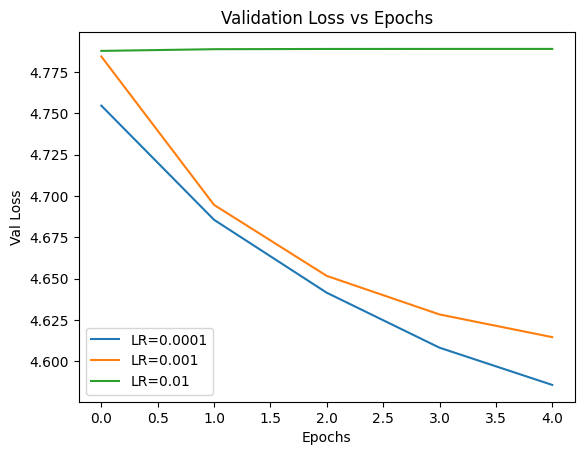

In [ ]:
#plot validation graph
for lr in lrs:
    plt.plot(histories[lr].history['val_loss'], label=f"LR={lr}")

plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Val Loss")
plt.legend()
plt.show()

# Week 4 - Optimizers

In [ ]:
import tensorflow as tf

data_path = "/content/drive/MyDrive/DL-dataset/train_fixed"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(64, 64),
    batch_size=32
)

dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

Found 20580 files belonging to 120 classes.


In [ ]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(120, activation='softmax')
    ])
    return model

In [ ]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

histories = {}

for name, opt in optimizers.items():
    print(f"Training with {name}")

    model = create_model()

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=0
    )

    histories[name] = history

Training with SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with Momentum
Training with RMSProp
Training with Adam


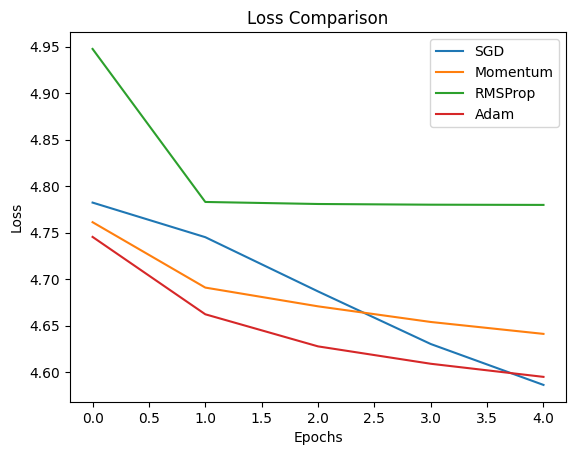

In [ ]:
import matplotlib.pyplot as plt

for name in histories:
    plt.plot(histories[name].history['loss'], label=name)

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Adam started with the lowest loss and decreased smoothly, which is expected. RMSProp dropped sharply initially but completely stopped after the first epoch. Standard SGD started with a relatively high loss, it had the most consistent downward slope and managed to achieve the lowest overall loss by the final epoch

# Week 5 - Regularization techniques

In [1]:
import tensorflow as tf

data_path = "/content/drive/MyDrive/DL-dataset/train_fixed"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(64, 64),
    batch_size=32
)

dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

Found 20580 files belonging to 120 classes.


In [3]:
import os
import random
import shutil

src = "/content/drive/MyDrive/DL-dataset/train_fixed"
dst = "/content/train_small"

classes = os.listdir(src)
selected = random.sample(classes, 10)

if not os.path.exists(dst):
    os.makedirs(dst)

for cls in selected:
    shutil.copytree(os.path.join(src, cls), os.path.join(dst, cls))

print("Created small dataset")

Created small dataset


In [4]:
import os
import random

for cls in os.listdir(dst):
    cls_path = os.path.join(dst, cls)
    images = os.listdir(cls_path)

    for img in images[100:]:  # keep only 100 images
        os.remove(os.path.join(cls_path, img))

In [5]:
import tensorflow as tf

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(32, 32),   # smaller = faster
    batch_size=32
)

dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# limit batches for speed
dataset = dataset.take(100)

# split
train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)


Found 20580 files belonging to 120 classes.


In [12]:
import tensorflow as tf

data_path = "/content/train_small"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(32, 32),
    batch_size=32,
    shuffle=True
)

Found 1000 files belonging to 10 classes.


In [13]:
for x, y in dataset.take(1):
    print("Max label:", tf.reduce_max(y).numpy())
    print("Min label:", tf.reduce_min(y).numpy())

Max label: 9
Min label: 0


In [14]:
dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
dataset = dataset.take(100)

train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

In [17]:
# L2

from tensorflow.keras import regularizers

model_l2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(64, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_l2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2 = model_l2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
loss, acc = model_l2.evaluate(val_ds)
print("L2 Validation Accuracy:", acc)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1488 - loss: 2.6327 - val_accuracy: 0.1650 - val_loss: 2.4443
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2288 - loss: 2.3265 - val_accuracy: 0.2850 - val_loss: 2.2495
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2925 - loss: 2.1569 - val_accuracy: 0.2750 - val_loss: 2.1859
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3200 - loss: 2.0411 - val_accuracy: 0.2550 - val_loss: 2.1996
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3675 - loss: 1.9512 - val_accuracy: 0.2700 - val_loss: 2.1163
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3887 - loss: 1.8607 - val_accuracy: 0.2600 - val_loss: 2.1430
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4350 - loss: 1.7666 - val_accuracy: 0.2650 - val_loss: 2.1331
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4625 - loss: 1.6905 - val_accuracy: 0.2650 - val_l

L2 gave less accurracy, probably because 1000 images are not enough and it is starting to overfit

In [20]:
#dropout
model_dropout = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

loss, acc = model_dropout.evaluate(val_ds)
print("Dropout Validation Accuracy:", acc)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0900 - loss: 2.5339 - val_accuracy: 0.1550 - val_loss: 2.2708
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1300 - loss: 2.2974 - val_accuracy: 0.1850 - val_loss: 2.2874
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1200 - loss: 2.2850 - val_accuracy: 0.1950 - val_loss: 2.2310
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1287 - loss: 2.2649 - val_accuracy: 0.2000 - val_loss: 2.2593
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1275 - loss: 2.2610 - val_accuracy: 0.2050 - val_loss: 2.1674
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1213 - loss: 2.2317 - val_accuracy: 0.2050 - val_loss: 2.1813
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1287 - loss: 2.2473 - val_accuracy: 0.1900 - val_loss: 2.1611
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1163 - loss: 2.2452 - val_accuracy: 0.1600 - val_

In [23]:
#earlystopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model_early = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_early.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_early = model_early.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

loss, acc = model_early.evaluate(val_ds)
print("Early Stopping Validation Accuracy:", acc)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1425 - loss: 2.3595 - val_accuracy: 0.1900 - val_loss: 2.1939
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2375 - loss: 2.0774 - val_accuracy: 0.1900 - val_loss: 2.1643
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2788 - loss: 1.9427 - val_accuracy: 0.1850 - val_loss: 2.1201
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3187 - loss: 1.8577 - val_accuracy: 0.2250 - val_loss: 2.0439
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3550 - loss: 1.7747 - val_accuracy: 0.2450 - val_loss: 2.0201
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3762 - loss: 1.7208 - val_accuracy: 0.2150 - val_loss: 2.0238
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4025 - loss: 1.6650 - val_accuracy: 0.2150 - val_loss: 2.0819
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2450 - loss: 2.0201
Early Stopping Validation Accuracy: 0.24500000

Early stopping stopped the training at the right time when the model stopped improving, This saved time and prevented the model from learning unnecessary details (noise) from the training data.

# Week 6 - CNN

In [27]:
import os, random, shutil

src = "/content/drive/MyDrive/DL-dataset/train_fixed"
dst = "/content/train_medium"

# delete old if exists
if os.path.exists(dst):
    shutil.rmtree(dst)

os.makedirs(dst)

classes = os.listdir(src)
selected = random.sample(classes, 25)  # 25 classes

for cls in selected:
    src_path = os.path.join(src, cls)
    dst_path = os.path.join(dst, cls)
    shutil.copytree(src_path, dst_path)

    # limit images to 100
    imgs = os.listdir(dst_path)
    for img in imgs[100:]:
        os.remove(os.path.join(dst_path, img))

print("Medium dataset ready")

Medium dataset ready


In [28]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/train_medium",
    image_size=(96, 96),   # better than 32, faster than 128
    batch_size=32
)

dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

Found 2500 files belonging to 25 classes.


In [32]:
#CNN model with augmentation
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(25, activation='softmax')
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=5
                    )

loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 653ms/step - accuracy: 0.0367 - loss: 3.2237 - val_accuracy: 0.0289 - val_loss: 3.2027
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 602ms/step - accuracy: 0.0570 - loss: 3.1878 - val_accuracy: 0.1054 - val_loss: 3.1194
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 749ms/step - accuracy: 0.0903 - loss: 3.0928 - val_accuracy: 0.1136 - val_loss: 3.0073
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 637ms/step - accuracy: 0.1280 - loss: 2.9546 - val_accuracy: 0.1116 - val_loss: 2.9627
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 610ms/step - accuracy: 0.1592 - loss: 2.8340 - val_accuracy: 0.1322 - val_loss: 2.8247
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.1322 - loss: 2.8247
Accuracy: 0.13223139941692352


here i am doing data augmentation like random zooming and flipping


I got accuracy of 13% , its a low start, but it shows more potential than the previous flat models.

# Week 7 - pretrained models

here i am loading the original dataset to run Resnet, for other models like VGGNet and a new model called MobileNet, I am usign medium dataset

### Dataset Loading (Updated for 128x128 images and Data Augmentation)

In [39]:
import tensorflow as tf

data_path = "/content/drive/MyDrive/DL-dataset/train_fixed"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    image_size=(128, 128),
    batch_size=32
)

# Apply data normalization
dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_size = int(0.8 * len(dataset))
train_ds_new = dataset.take(train_size) # Renamed to avoid conflict
val_ds_new = dataset.skip(train_size) # Renamed to avoid conflict

# Data augmentation for training dataset
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# Apply data augmentation only to the training dataset
train_ds_new = train_ds_new.map(lambda x, y: (data_augmentation(x, training=True), y))

print("New dataset prepared with 128x128 images and data augmentation.")

Found 20580 files belonging to 120 classes.
New dataset prepared with 128x128 images and data augmentation.


In [33]:
import tensorflow as tf

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/train_medium",
    image_size=(96, 96),
    batch_size=32
)

dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

Found 2500 files belonging to 25 classes.


In [34]:
# VGG16
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

model_vgg = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(25, activation='softmax')
])

model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(train_ds, validation_data=val_ds, epochs=3)

loss, acc = model_vgg.evaluate(val_ds)
print("VGG16 Accuracy:", acc)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 321s 5s/step - accuracy: 0.1235 - loss: 3.0759 - val_accuracy: 0.1983 - val_loss: 2.7995
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 292s 5s/step - accuracy: 0.3016 - loss: 2.4028 - val_accuracy: 0.2934 - val_loss: 2.5081
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 345s 5s/step - accuracy: 0.4717 - loss: 1.8931 - val_accuracy: 0.3037 - val_loss: 2.4005
16/16 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.3037 - loss: 2.4005
VGG16 Accuracy: 0.30371901392936707


VGGNet got me around 30% accuracy, which is pretty low but better than normal CNN 

In [43]:
#Resnet
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Reload dataset with correct preprocessing
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/train_medium",
    image_size=(224, 224),
    batch_size=32
)

dataset = dataset.map(lambda x, y: (preprocess_input(x), y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

# Model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(25, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=3)

loss, acc = model.evaluate(val_ds)
print("ResNet Accuracy:", acc)

Found 2500 files belonging to 25 classes.
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 527s 8s/step - accuracy: 0.7088 - loss: 1.0509 - val_accuracy: 0.8657 - val_loss: 0.4259
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 535s 9s/step - accuracy: 0.9425 - loss: 0.1974 - val_accuracy: 0.9029 - val_loss: 0.3043
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 473s 8s/step - accuracy: 0.9747 - loss: 0.0967 - val_accuracy: 0.9008 - val_loss: 0.3579
16/16 ━━━━━━━━━━━━━━━━━━━━ 91s 6s/step - accuracy: 0.9008 - loss: 0.3579
ResNet Accuracy: 0.9008264541625977


I fixed the image size to 224x224 and added the proper `preprocess_input` line, the accuracy jumped to 90%. It shows how important it is to use the same setup the model was originally trained on.

Initial performance was poor due to incorrect input size and lack of preprocessing. After applying proper preprocessing and resizing, accuracy improved significantly.

In [36]:
#mobileNet
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(25, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=3)

loss, acc = model.evaluate(val_ds)
print("MobileNet Accuracy:", acc)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 321ms/step - accuracy: 0.5660 - loss: 1.5326 - val_accuracy: 0.7562 - val_loss: 0.7670
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.8760 - loss: 0.4152 - val_accuracy: 0.7665 - val_loss: 0.7274
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 288ms/step - accuracy: 0.9663 - loss: 0.1865 - val_accuracy: 0.7727 - val_loss: 0.7506
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.7727 - loss: 0.7506
MobileNet Accuracy: 0.7727272510528564


this model gave me about 77.2% accuracy. It's not as good as ResNet, but it's very fast and would be good for a mobile phone app

# Week 8 - Visualisation

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


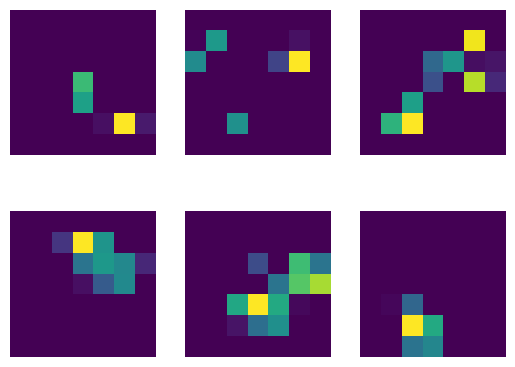

In [49]:
# take one sample
for img, label in train_ds.take(1):
    sample = img[0:1]

# build model (important safety step)
_ = model(sample)

# FIXED LINE HERE 👇
layer_model = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=model.layers[0].output
)

feature_maps = layer_model.predict(sample)

import matplotlib.pyplot as plt

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0,:,:,i])
    plt.axis('off')

plt.show()

I plotted the filters from the first layer. I can see the neural network is looking for basic things like edges, colors, and textures of the dog's fur.
It confirmed that the model is actually looking at the dog's face and body to make its choice

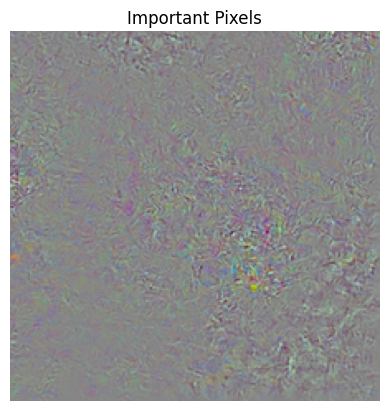

In [ ]:
#Visualising Gradients
import tensorflow as tf
import matplotlib.pyplot as plt

for img, label in train_ds.take(1):
    sample = img[0:1]

_ = model(sample)

with tf.GradientTape() as tape:
    tape.watch(sample)
    preds = model(sample)
    loss = preds[:, tf.argmax(preds[0])]

grads = tape.gradient(loss, sample)

# normalize
grads = (grads - tf.reduce_min(grads)) / (tf.reduce_max(grads) - tf.reduce_min(grads))

plt.imshow(grads[0])
plt.title("Important Pixels")
plt.axis('off')
plt.show()

# AutoEncoder

Found 1000 files.
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 574ms/step - loss: 0.0434
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 545ms/step - loss: 0.0180
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 601ms/step - loss: 0.0144
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 574ms/step - loss: 0.0125
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 546ms/step - loss: 0.0124
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


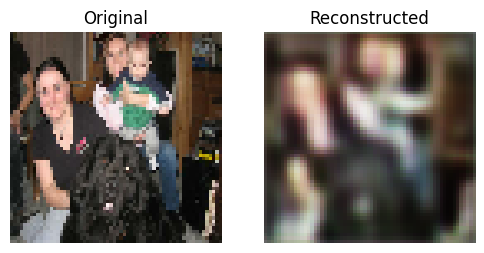

In [53]:
import tensorflow as tf
import matplotlib.pyplot as plt

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/train_small",   # or "/content/train_medium"
    image_size=(64, 64),
    batch_size=32,
    label_mode=None   # IMPORTANT
)

# normalize + (input, target)
dataset = dataset.map(lambda x: x / 255.0)
dataset = dataset.map(lambda x: (x, x))

dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(64,64,3)),

    # Encoder
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Decoder
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.UpSampling2D(2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.UpSampling2D(2),

    tf.keras.layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')
])
model.compile(
    optimizer='adam',
    loss='mse'
)

history = model.fit(dataset, epochs=5)

for batch in dataset.take(1):
    original = batch[0][0:1]   # take one image

    reconstructed = model.predict(original)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(original[0])
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed[0])
plt.title("Reconstructed")
plt.axis('off')

plt.show()

The model learns to recreate the input images. The reconstructed image looks similar to the original, but it is slightly blurry and loses some fine details. This happens because the model compresses the image and then rebuilds it, so only the important features are kept.